In [6]:
import os
import numpy as np
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["NUMBA_THREADING_LAYER"
] = "workqueue"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"
import stark as sk


In [7]:
# ==========================================
# 0. 初始化核心数据对象 HData
# ==========================================
print(">>> 初始化 HData 对象...")
resolutions = [ 50000,500000, 1000000,]
hdata = sk.HData(
    data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
    output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
    genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
    chrom_list=[f"chr{i}" for i in range(1, 23)],
    resolutions=resolutions
)

>>> 初始化 HData 对象...


In [8]:
hdata

HData object with 0 cells and 0 metacells
    resolutions: [50000, 500000, 1000000]
    obs: []
    views_pca: []
    views_umap: []
    views_embedding: []
    views_mat: []
    views_is: []
    uns keys: []

In [9]:
# ==========================================
# 1. 执行数据预处理与加载
# ==========================================
print("\n>>> 1. 执行数据预处理与加载...")
sk.pp.process_and_load(
    hdata, 
    force_process=True, 
    cpu_num=10, 
    gpu_num=8
)


>>> 1. 执行数据预处理与加载...
====== calculating depth =======
Depth file already exists. Skipping depth calculation.
====== depth calculation completed =======
====== Processing multiple resolutions =======
====== Processing resolution: 50000 =======
Files for resolution 50000 already exist. Skipping processing.
====== Processing resolution: 500000 =======
Files for resolution 500000 already exist. Skipping processing.
====== Processing resolution: 1000000 =======
Files for resolution 1000000 already exist. Skipping processing.
✅ 数据底层处理 (stark_process) 完成。
✅ 数据已成功挂载到 HData 对象中。


In [ ]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])

In [11]:
lb = ['ExcNeuron' if x in ['L23', 'L4', 'L5', 'L6'] else x for x in lb]

In [12]:
hdata.obs['label'] = lb

In [13]:
hdata

HData object with 700 cells and 0 metacells
    resolutions: [50000, 500000, 1000000]
    obs: ['depth', 'label']
    views_pca: [50000, 500000, 1000000]
    views_umap: [50000, 500000, 1000000]
    views_embedding: [50000, 500000, 1000000]
    views_mat: [50000, 500000, 1000000]
    views_is: []
    uns keys: []

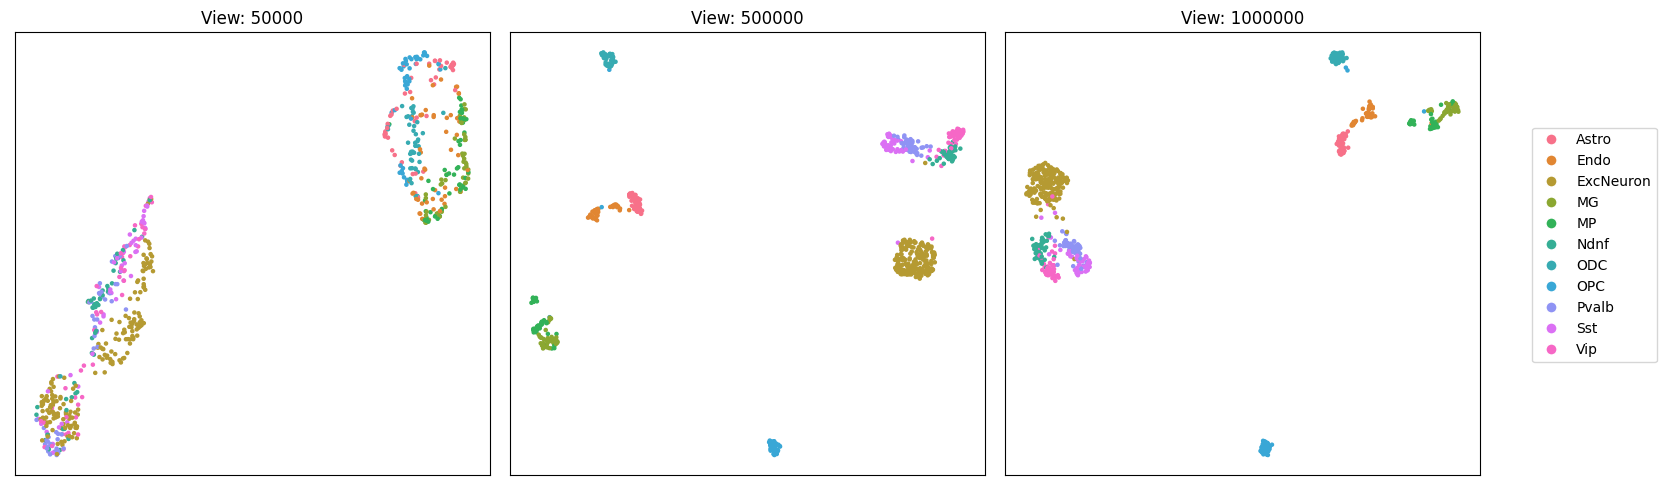

In [14]:
sk.pl.plot_views(hdata)

mean_depth:0.11M


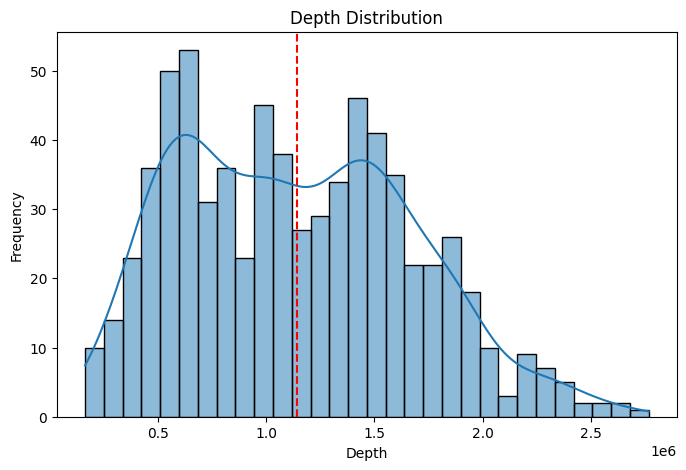

In [15]:
sk.pl.plot_depth_distribution(hdata)


>>> 2. 推荐 MetaCell 数量...
推荐 MetaCell 数量的目标测序深度范围: 30000000.00 - 200000000.00
正在构建 AnnData 并计算近邻图 (n_neighbors=30)...
正在执行 Leiden 聚类 (resolution=1.5)...
✅ 聚类完成，共发现 10 个聚类簇。

💡 基于 Leiden 聚类的推荐结果: 最终总 n_metacells 范围 = [10, 27]


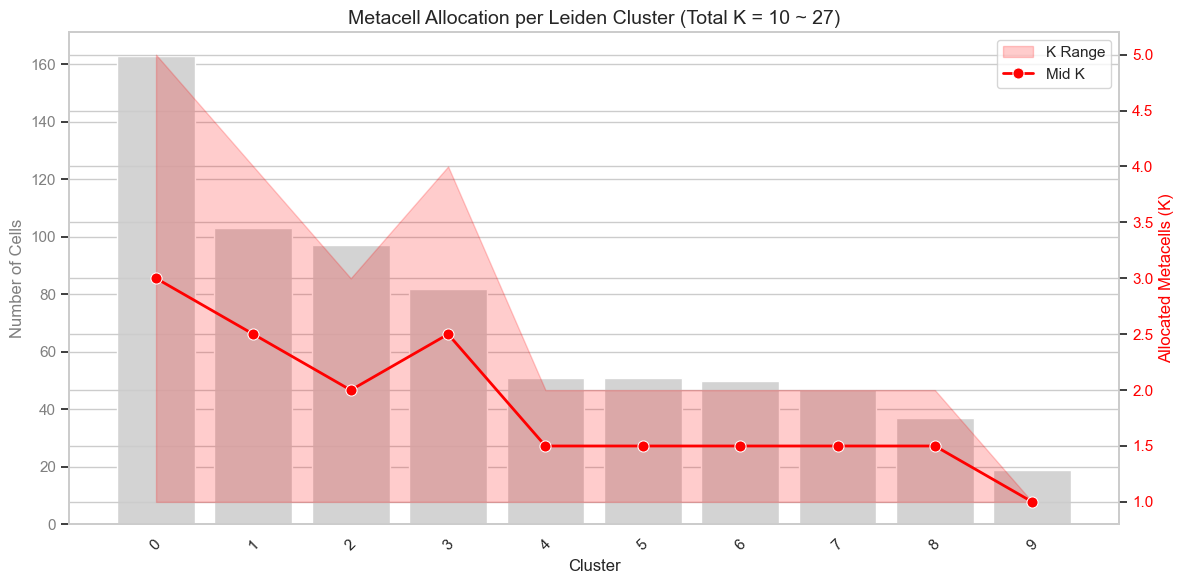

In [62]:
# ==========================================
# 2. 推荐 MetaCell 数量 (带原有参数)
# ==========================================
print("\n>>> 2. 推荐 MetaCell 数量...")
min_depth = 30000000
max_depth = 200000000
print(f"推荐 MetaCell 数量的目标测序深度范围: {min_depth:.2f} - {max_depth:.2f}")
min_k, max_k = sk.tl.recommend_metacell_num(
    hdata,
    target_depth_min=min_depth,  # 下限 20M
    target_depth_max=max_depth ,  # 上限 40M
    resolution_param=1.5,     # Leiden resolution
    n_neighbors=30,
    ref_view=500000,
    
)

In [17]:
# # ==========================================
# # 3. 初始化模型参数 (还原所有原有超参数)
# # ==========================================
# print("\n>>> 3. 初始化模型参数...")
sk.tl.init_model(
    hdata, 
    n_metacells=12, # 25,            # 目标 MetaCell 数量
    lambda_balance=0.5,       # 平衡惩罚
    lambda_consistency=0.010,  # 一致性惩罚
adaptive_weight=True,
    max_iter=100,              # 最大迭代次数
    # --- scHi-C 深度优化参数 ---
    min_size_threshold=0.002,  # 重生阈值
    respawn_interval=100,       # 检查频率
    split_metric='pca',         # 分裂准则
    weight_method='consensus',
    lambda_ortho=0.001
    # weight_momentum=0.99,
)


✅ 模型参数初始化完成，目标 MetaCell 数量: 12


In [18]:
# ==========================================
# 4. 计算核矩阵
# ==========================================
print("\n>>> 4. 计算核矩阵...")
sk.tl.compute_kernels(hdata, )
# sk.tl.compute_kernels(hdata, use_ps=True)
# sk.tl.compute_kernels(hdata, use_ps=False)÷


>>> 4. 计算核矩阵...
步骤1: 构建核矩阵 (Cache Dir: None)
  [View 0] 开始内部计算 RBF 核矩阵 (Input: (700, 68))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:91: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  [View 1] 开始内部计算 RBF 核矩阵 (Input: (700, 114))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:91: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


  [View 2] 开始内部计算 RBF 核矩阵 (Input: (700, 123))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:91: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)



>>> 5. 初始化 Waypoints (K-Means++)...

步骤2: 参数初始化 (Method: Micro-Clustering on PCA features)
  执行 MiniBatchKMeans (k=300)...
  最终选中 12 个 Waypoints


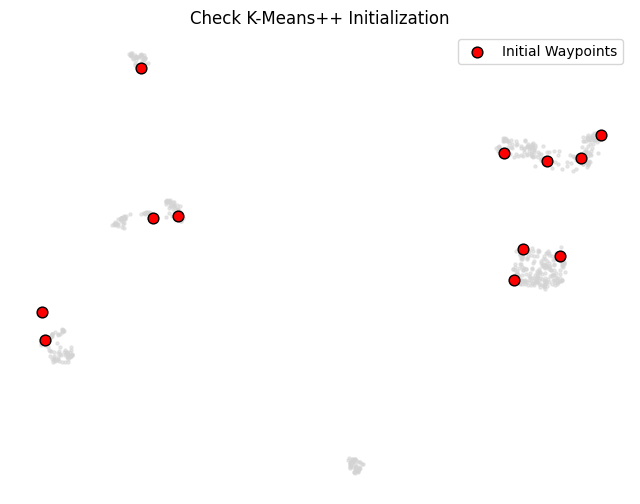

In [19]:
# ==========================================
# 5. 初始化 Waypoint (还原原有初始化参数)
# ==========================================
print("\n>>> 5. 初始化 Waypoints (K-Means++)...")
sk.tl.initialize_waypoints(
    hdata, 
    data_type='pca', 
    seed=32, 
    n_micro_clusters=300,       # 对应原代码中的 30
    ref_view_res=1000000
)
sk.pl.plot_initialization(hdata,resolution=500000, title="Check K-Means++ Initialization")



In [20]:
# ==========================================
# 6. 核心拟合优化
# ==========================================
print("\n>>> 6. 开始模型拟合优化...")
sk.tl.fit(hdata, n_threads=10)


>>> 6. 开始模型拟合优化...

步骤4: 联合优化 (Split Metric: pca)
Iter   0 | Loss: 1959.5043 | Size Range: 51.8-67.6 | weight: [0.33333333 0.33333333 0.33333333]
Iter  10 | Loss: 1747.0707 | Size Range: 47.6-61.4 | weight: [0.20664844 0.41967458 0.37367698]
Iter  20 | Loss: 1739.9344 | Size Range: 49.6-65.6 | weight: [0.15016844 0.46198638 0.38784518]
Iter  30 | Loss: 1734.1913 | Size Range: 47.3-64.0 | weight: [0.13097182 0.4714571  0.39757108]
Iter  40 | Loss: 1705.1801 | Size Range: 55.6-60.9 | weight: [0.11909293 0.47461407 0.40629301]
Iter  50 | Loss: 1708.1552 | Size Range: 55.0-63.6 | weight: [0.11895609 0.480793   0.4002509 ]
Iter  60 | Loss: 1715.5377 | Size Range: 55.5-61.0 | weight: [0.12019214 0.47798466 0.4018232 ]
Iter  70 | Loss: 1717.3996 | Size Range: 53.0-62.3 | weight: [0.11860932 0.47995766 0.40143302]
Iter  80 | Loss: 1711.6538 | Size Range: 56.7-62.5 | weight: [0.12114029 0.4778616  0.4009981 ]
Iter  90 | Loss: 1711.1529 | Size Range: 53.9-62.0 | weight: [0.12144198 0.47884119 0


>>> 7-10. 绘图与评估...


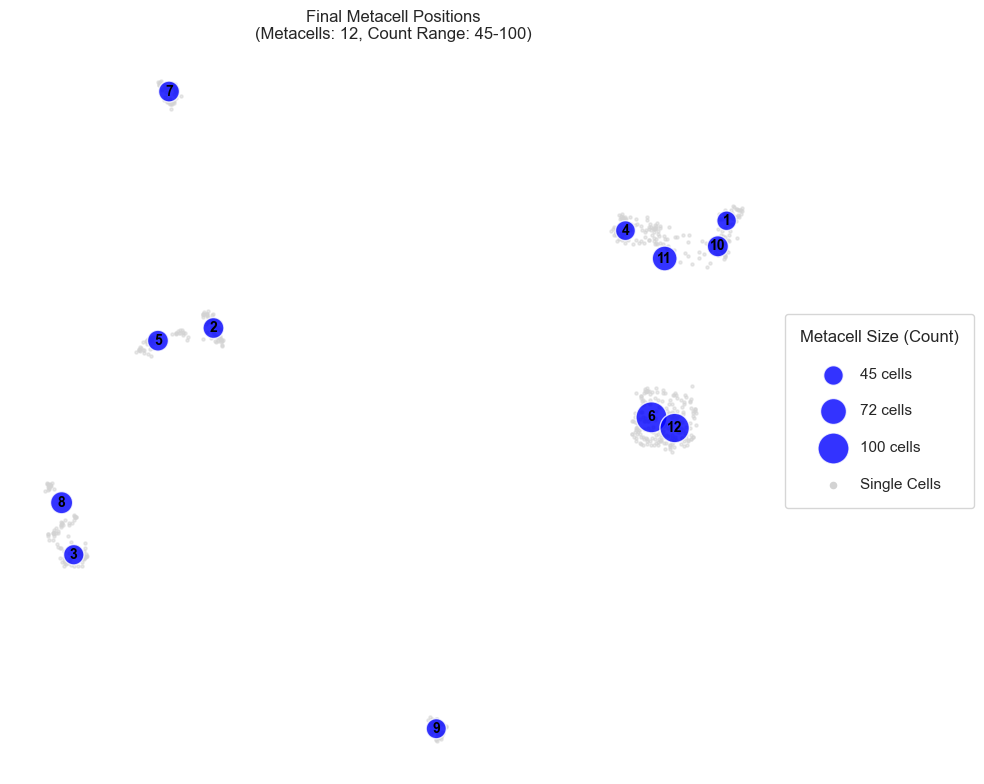

In [26]:


# ==========================================
# 7 - 10. 后续评估与可视化
# ==========================================
print("\n>>> 7-10. 绘图与评估...")
sk.pl.plot_metacells(hdata, resolution=500000, max_size=500, min_size=200,show_idx=True)



正在计算评估指标...
✅ 指标计算完成！(发现 11 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.8996
模型准确率 (Accuracy)      : 0.9043
全局加权分 (Global Score)  : 0.7791
过度融合指标 (WCOS)       : 0.9614
Hub 权重不纯度 (HWIS)     : 0.9922
----------------------------------------
✅ 评估指标计算完成，纯度得分(EP_v2等)已同步至 hdata.metacells。


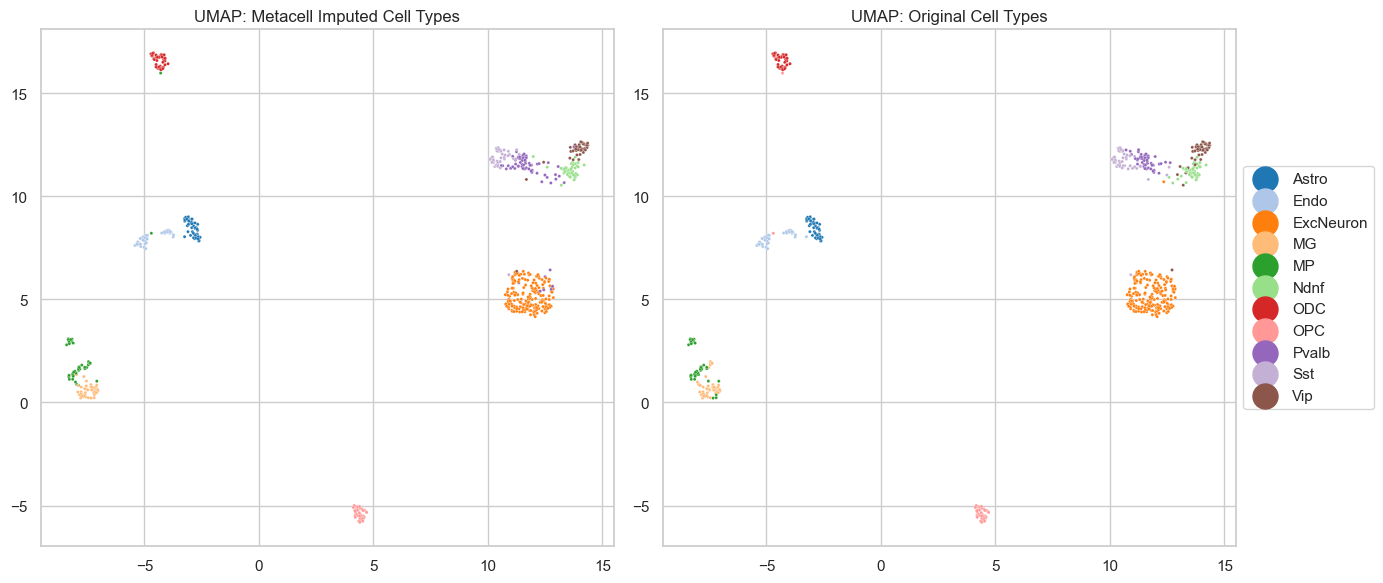


🎉 全流程运行完毕！


In [27]:
# 执行评估
purity_df, metrics = sk.tl.evaluate(hdata, hdata.obs['label'])

# 最终对比图
sk.pl.plot_umap_comparison(hdata, resolution=500000)

print("\n🎉 全流程运行完毕！")

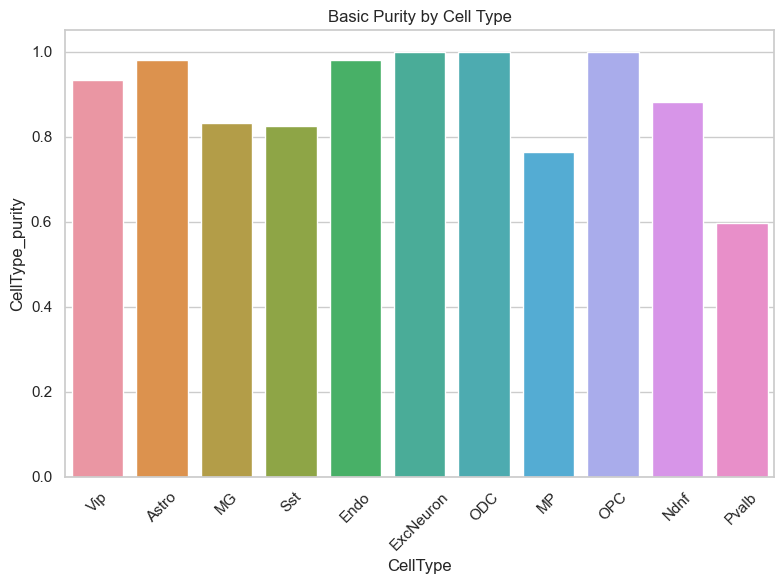

In [28]:
sk.pl.plot_basic_purity(hdata,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


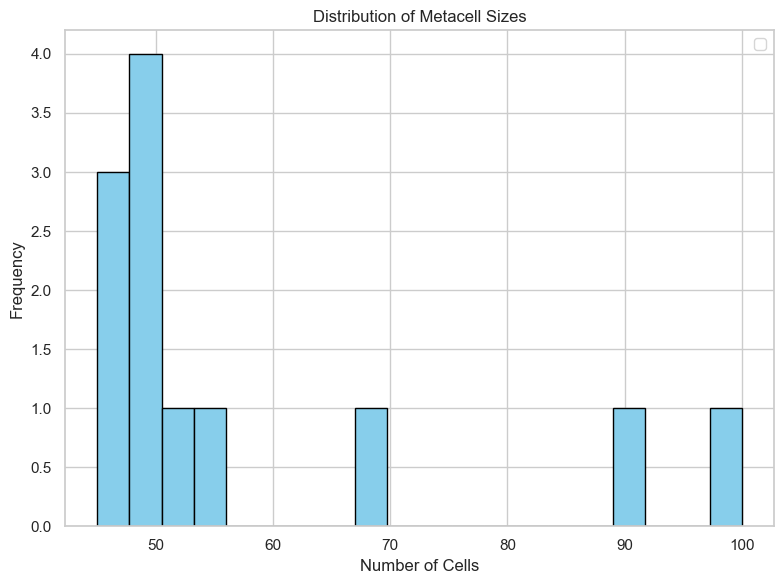

In [29]:
sk.pl.plot_metacell_sizes(hdata,)

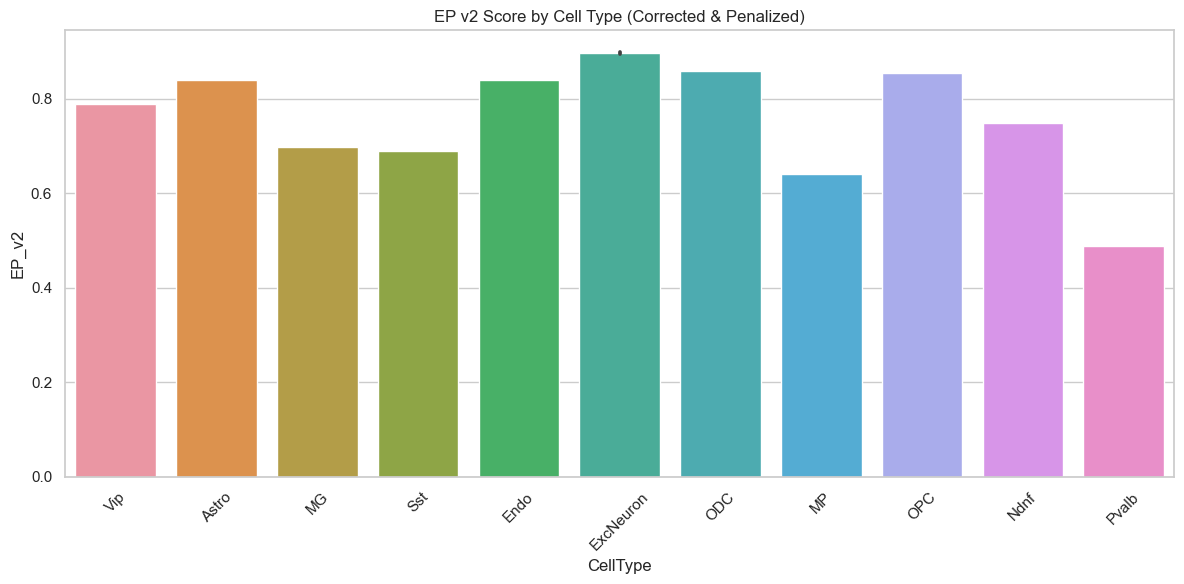

In [30]:
sk.pl.plot_ep_score(hdata)

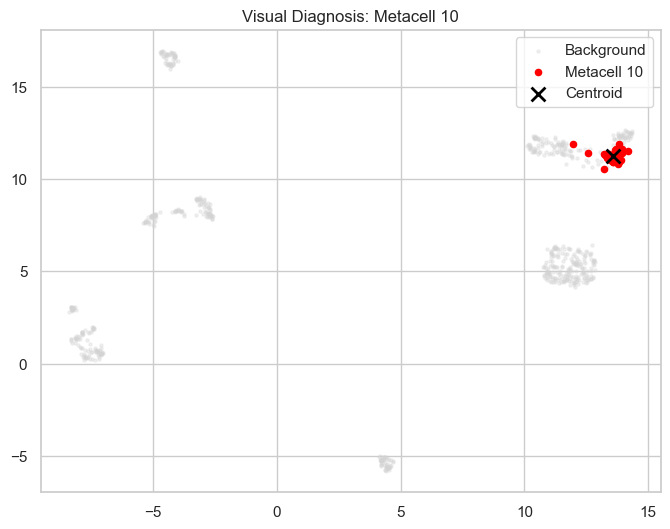

In [31]:
sk.pl.plot_specific_metacell(hdata, metacell_id=10, resolution=500000)


/Users/ckw/warehouse/metacell/stark/stark/pl/plot_m.py:413: UserWarning: The handle <matplotlib.collections.PathCollection object at 0x3fbb05510> has a label of '_child11' which cannot be automatically added to the legend.
  plt.legend(handles=handles, title="Metacell Legend", loc='center left', bbox_to_anchor=(1, 0.5), labelspacing=1.0, borderpad=1)


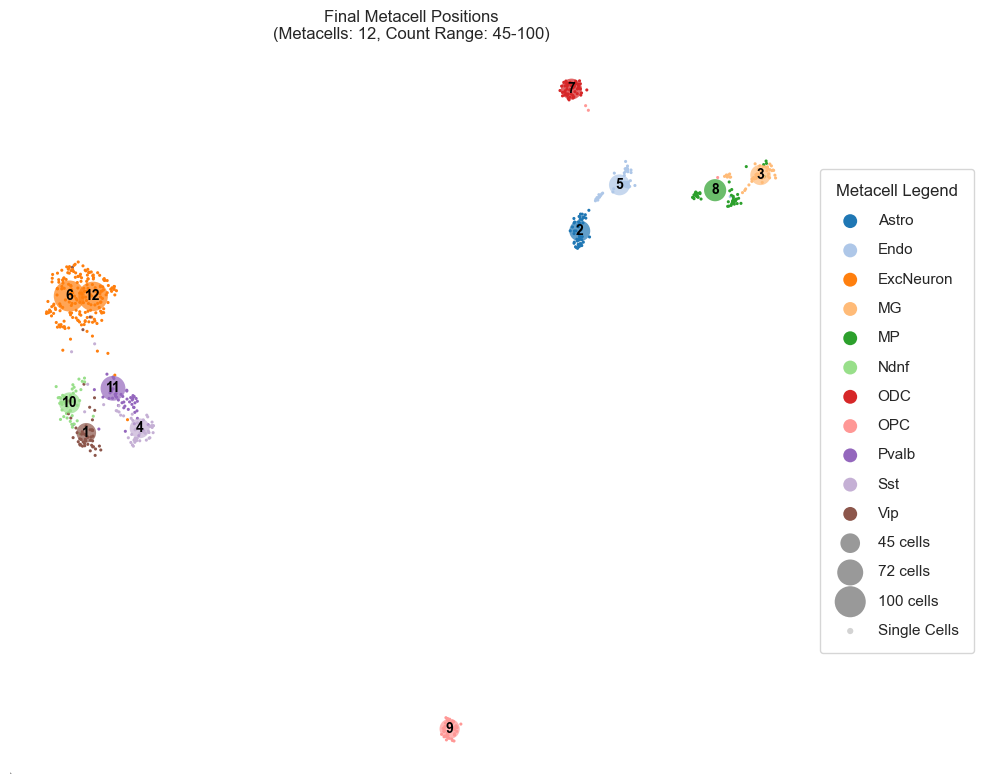

In [33]:
sk.pl.plot_metacells2(hdata, resolution=1000000, title="Final Metacell Positions",
             min_size=200, max_size=500, 
             show_idx=True, label_col='label', 
             cell_alpha=1, metacell_alpha=0.7)


In [50]:
chrom = 'chr1'
resolution = 500000
start =0
end=198022430//2

In [51]:
sk.tl.aggregate_metacell_pairs(hdata,  n_jobs=2, force_aggregate=False, 
                             convert_to_cool=True, convert_to_mcool=True,
                             resolution=10000, mcool_resolutions=[ 50000, 100000,500000, 1000000,2000000], verbose=True)

# ,2000000

>>> 检测到分配映射与聚合参数均未改变，且文件完整，跳过所有重复生成。

✅ 聚合流程完成。Metacell 文件路径与信息已存入 hdata。
HData object with 700 cells and 12 metacells
    resolutions: [50000, 100000, 500000, 1000000, 2000000]
    obs: ['depth', 'label', 'metacell']
    views_pca: [50000, 500000, 1000000]
    views_umap: [50000, 500000, 1000000]
    views_embedding: [50000, 500000, 1000000]
    views_mat: [50000, 500000, 1000000]
    views_is: []
    uns keys: ['recommended_k', 'purity_df', 'metrics', 'eval_df_cache', 'avg_size_cache', 'thre_cache', 'accuracy', 'global_score', 'wcos', 'hwis']
    metacells: ['CellType', 'CellType_purity', 'cell_num', 'w_min', 'w_max', 'P_adj', 'EP_v2', 'total_depth', 'cell_count', 'mean_depth', 'dominant_label']
    metacell_data keys: ['pairs', 'cool', 'mcool', 'mat']
    model: MultiViewSEACells (trained: True)



⏭️  分辨率 50000 已存在聚合结果，跳过 (使用 force_aggregate=True 强制重跑)。
⏭️  分辨率 500000 已存在聚合结果，跳过 (使用 force_aggregate=True 强制重跑)。
⏭️  分辨率 1000000 已存在聚合结果，跳过 (使用 force_aggregate=True 强制重跑)。

✅ 全量聚合完成！
   可通过 base_on='mat' 方式可视化的分辨率: [50000, 500000, 1000000]
   调用示例: sk.pl.plot_metacell_heatmap(hdata, ..., resolution=50000, base_on='mat')
共找到 1 个属于 'OPC' 的 Metacells, 准备渲染...


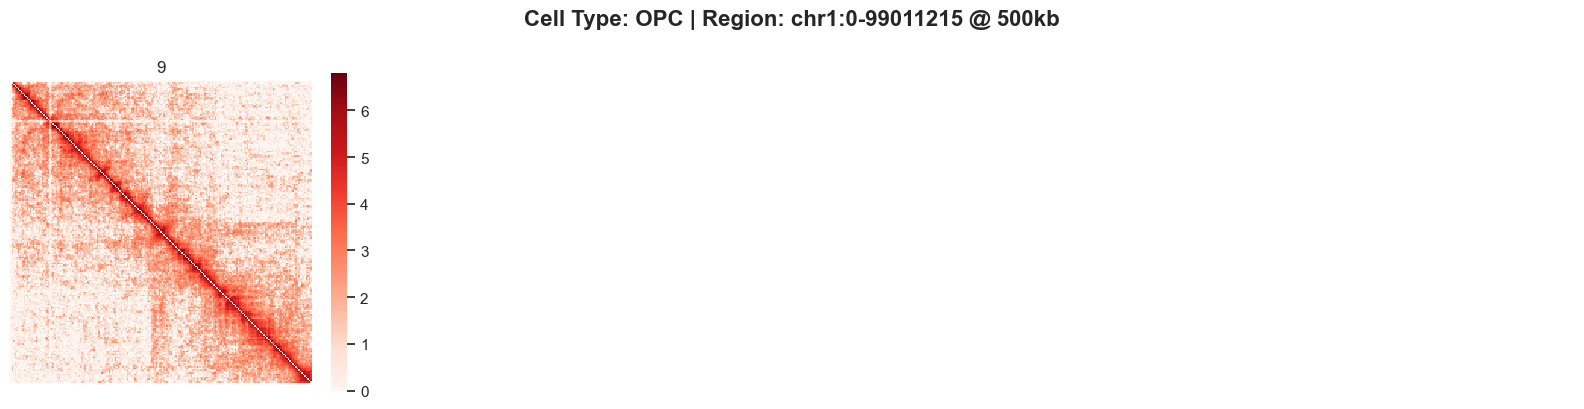

In [52]:
# 1. 直接全内存聚合生成 mat (不需要跑 pair/cool/mcool)
sk.tl.aggregate_metacell_mat(hdata, force_aggregate=False)

# 2. 画图验证 (通过 base_on="mat" 一键路由)
sk.pl.plot_celltype_heatmaps(hdata, cell_type='OPC', chrom=chrom, 
                                start=start, 
                                end=end, 
                                resolution=resolution, 
                                base_on='mat',
                                cell_type_col='dominant_label',balance=False)


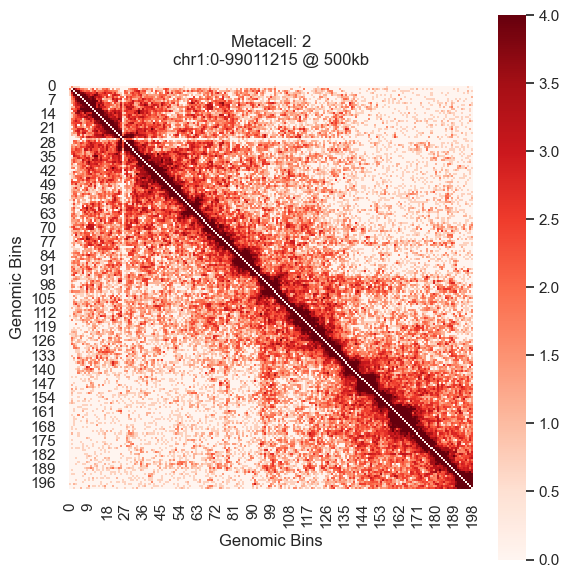

array([[0.        , 1.60943791, 0.69314718, ..., 0.69314718, 0.        ,
        0.        ],
       [1.60943791, 0.        , 5.25749537, ..., 0.        , 0.        ,
        0.        ],
       [0.69314718, 5.25749537, 0.        , ..., 1.09861229, 0.        ,
        0.69314718],
       ...,
       [0.69314718, 0.        , 1.09861229, ..., 0.        , 5.23110862,
        4.67282883],
       [0.        , 0.        , 0.        , ..., 5.23110862, 0.        ,
        5.39362755],
       [0.        , 0.        , 0.69314718, ..., 4.67282883, 5.39362755,
        0.        ]])

In [53]:
sk.pl.plot_metacell_heatmap(hdata=hdata,
                            metacell_id=2,
                            chrom=chrom,
                            start=start,
                            end=end,
                            resolution=resolution,
                            balance=False,
                            base_on='pair',
                            log1p=True,
                            vmax=4,
                            fill_diagonal_zero=True)

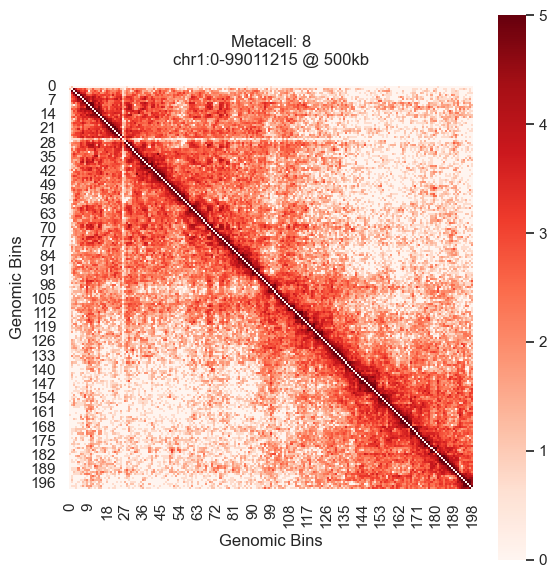

array([[0.       , 1.0986123, 0.       , ..., 0.       , 0.       ,
        0.       ],
       [1.0986123, 0.       , 4.962845 , ..., 0.       , 0.6931472,
        0.       ],
       [0.       , 4.962845 , 0.       , ..., 0.       , 0.6931472,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 5.598422 ,
        4.2341065],
       [0.       , 0.6931472, 0.6931472, ..., 5.598422 , 0.       ,
        4.983607 ],
       [0.       , 0.       , 0.       , ..., 4.2341065, 4.983607 ,
        0.       ]], dtype=float32)

In [54]:
sk.pl.plot_metacell_heatmap(hdata=hdata, 
                            metacell_id=8,
                            chrom=chrom,
                            balance=False,
                            resolution=resolution,
                            start=start,
                            log1p=True,
                            end=end,
                            vmax=5,
                            base_on='mat',            # 【关键】使用极速的内存矩阵模式_)
)


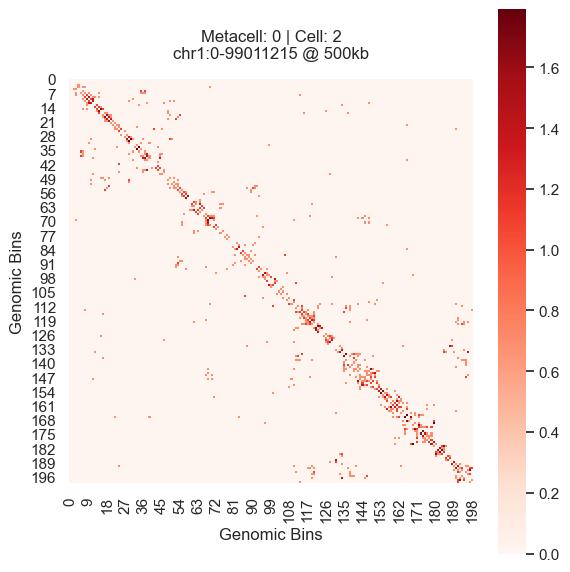

In [55]:

mat = sk.pl.plot_cell_of_metacell_heatmap(hdata,
                                    metacell_id=0, 
                                    cell_id=2, 
                                    chrom=chrom, 
                                    start=start, 
                                    end=end, 
                                    resolution=resolution, 
                                    balance=False, 
                                    base_on='mat', 
                                    cmap='Reds')




共找到 12 个 Metacells, 准备渲染...


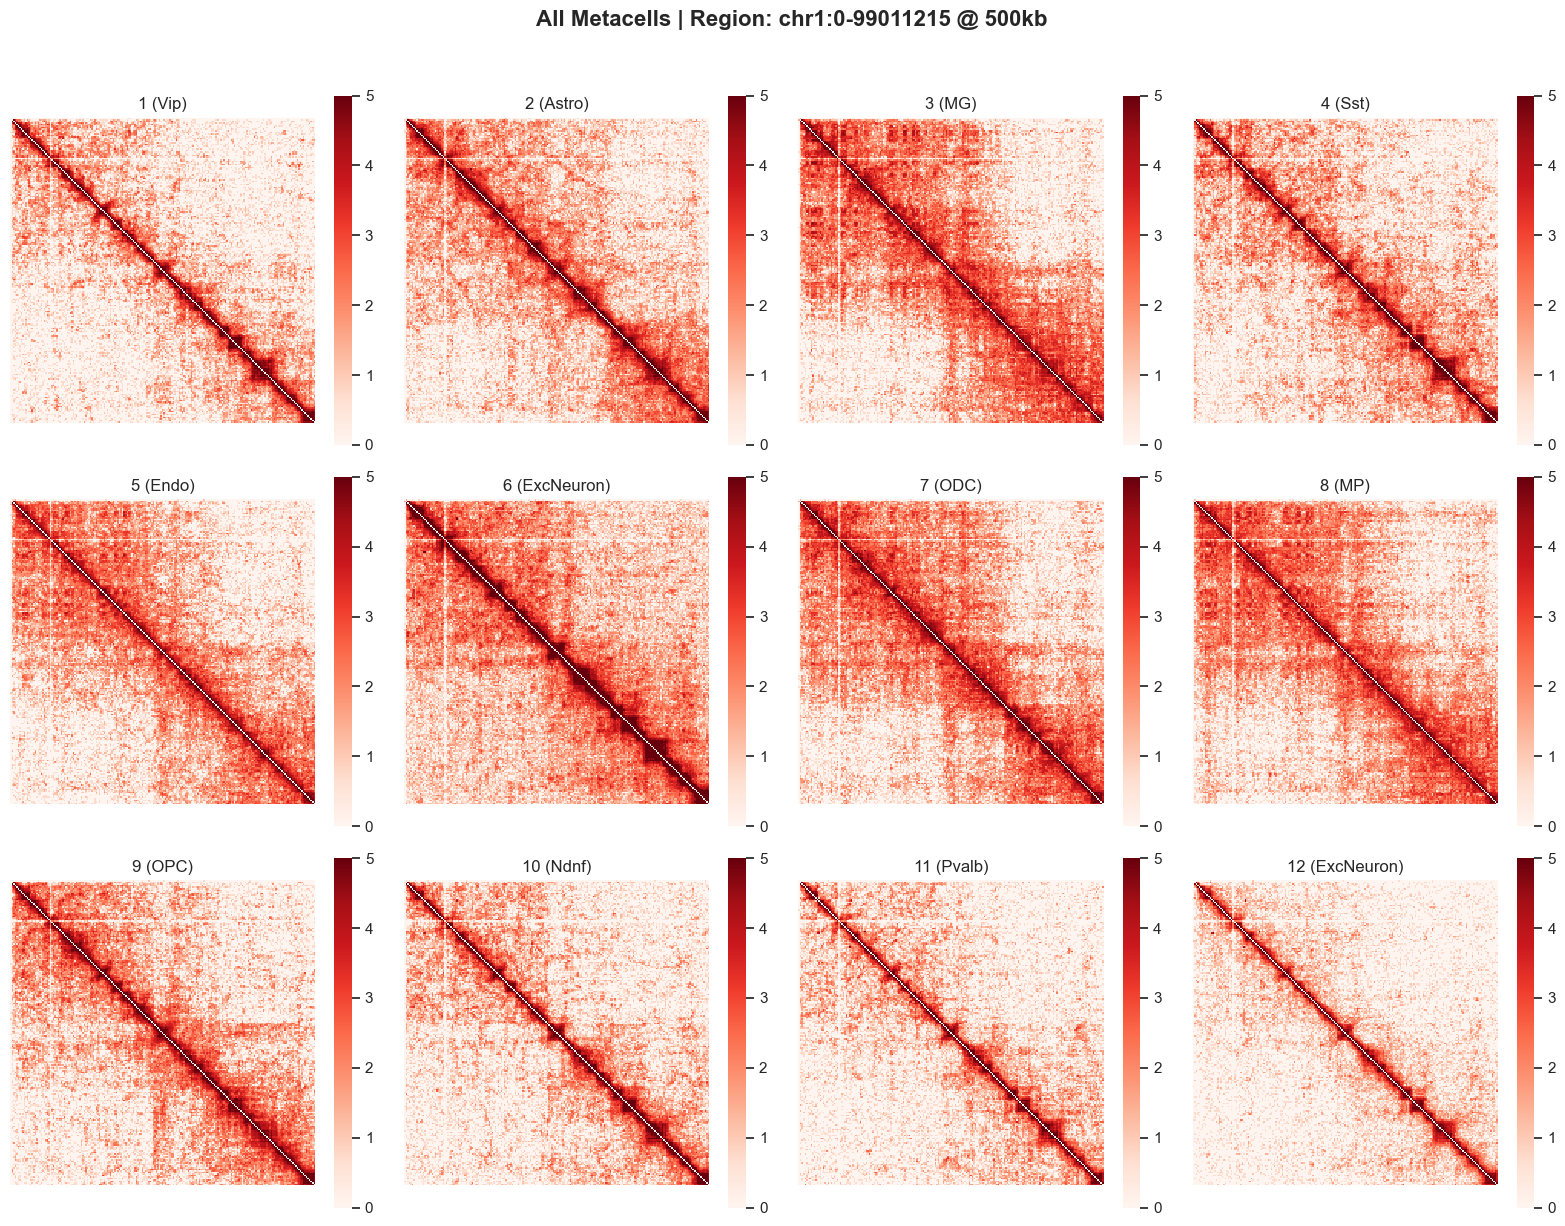

In [58]:
sk.pl.plot_metacell_region(hdata, chrom, start, end, resolution,
                         balance=True, base_on='mat', ncols=4, celltype=None,
                         cell_type_col='dominant_label', cmap='Reds',vmax=5,named_on='CellType',
                         log1p=True, fill_diagonal_zero=True,)

In [57]:
hdata.metacells

,CellType,CellType_purity,cell_num,w_min,w_max,P_adj,EP_v2,total_depth,cell_count,mean_depth,dominant_label
Metacell,,,,,,,,,,,
1,Vip,0.933333,45,0.850929,1.0,0.926667,0.788527,52491204,45,1.166471e+06,Vip
2,Astro,0.980000,50,0.858579,1.0,0.978000,0.839690,62032246,50,1.240645e+06,Astro
3,MG,0.833333,48,0.855662,1.0,0.816667,0.698791,64163763,48,1.336745e+06,MG
4,Sst,0.826087,46,0.852558,1.0,0.808696,0.689460,54844390,46,1.192269e+06,Sst
5,Endo,0.980000,50,0.858579,1.0,0.978000,0.839690,55809405,50,1.116188e+06,Endo
6,ExcNeuron,1.000000,100,0.900000,1.0,1.000000,0.900000,133826633,100,1.338266e+06,ExcNeuron
7,ODC,1.000000,50,0.858579,1.0,1.000000,0.858579,69264262,50,1.385285e+06,ODC
8,MP,0.763636,55,0.865160,1.0,0.740000,0.640218,64602296,55,1.174587e+06,MP
9,OPC,1.000000,47,0.854135,1.0,1.000000,0.854135,61821976,47,1.315361e+06,OPC
